In [1]:
import os
from PIL import Image
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import efficientnet_b0


CNRPARK_PATH = "/Users/romeshjain/Desktop/DL Parking Allocation/Dataset/CNRPark-Patches-150x150"
CNREXT_PATH = "/Users/romeshjain/Desktop/DL Parking Allocation/Dataset/CNR-EXT-Patches-150x150"


transform = transforms.Compose([
    transforms.Resize((64, 64)),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


class ParkingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
       
        for camera in ["A", "B"]:
            for label in ["free", "busy"]:
                label_path = os.path.join(root_dir, camera, label)
                for img_name in os.listdir(label_path):
                    img_path = os.path.join(label_path, img_name)
                    self.image_paths.append(img_path)
                    self.labels.append(0 if label == "free" else 1)

    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


train_dataset = ParkingDataset(CNRPARK_PATH, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# EfficientNet-B0 with pretrained weights and modify for binary classification
efficientnet = efficientnet_b0(pretrained=True)
efficientnet.classifier[1] = nn.Linear(efficientnet.classifier[1].in_features, 2)
efficientnet = efficientnet.to(device)

# Freezing early layers to reduce training time
for param in efficientnet.features.parameters():
    param.requires_grad = False

# Defining loss function and optimizer (using SGD for lighter computations)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(efficientnet.parameters(), lr=0.01, momentum=0.9)

# Training loop
epochs = 5
for epoch in range(epochs):
    efficientnet.train()
    running_loss = 0.0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = efficientnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
       
        if (batch_idx + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item()}")
    
    
    print(f"Epoch {epoch+1}/{epochs}, Average Loss: {running_loss / len(train_loader)}")

print("Training complete.")


/Users/romeshjain/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2.0 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/romeshjain/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/romeshjain/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/5, Batch 10/1573, Loss: 0.4052259922027588
Epoch 1/5, Batch 20/1573, Loss: 0.5264531970024109
Epoch 1/5, Batch 30/1573, Loss: 0.12681494653224945
Epoch 1/5, Batch 40/1573, Loss: 0.008124123327434063
Epoch 1/5, Batch 50/1573, Loss: 1.629680871963501
Epoch 1/5, Batch 60/1573, Loss: 0.6874700784683228
Epoch 1/5, Batch 70/1573, Loss: 0.06858553737401962
Epoch 1/5, Batch 80/1573, Loss: 0.14763814210891724
Epoch 1/5, Batch 90/1573, Loss: 0.40789714455604553
Epoch 1/5, Batch 100/1573, Loss: 0.06443583965301514
Epoch 1/5, Batch 110/1573, Loss: 1.2482504844665527
Epoch 1/5, Batch 120/1573, Loss: 0.00692756799980998
Epoch 1/5, Batch 130/1573, Loss: 0.29912102222442627
Epoch 1/5, Batch 140/1573, Loss: 1.4930393695831299
Epoch 1/5, Batch 150/1573, Loss: 0.29098525643348694
Epoch 1/5, Batch 160/1573, Loss: 0.039133742451667786
Epoch 1/5, Batch 170/1573, Loss: 1.0705885887145996
Epoch 1/5, Batch 180/1573, Loss: 0.10247674584388733
Epoch 1/5, Batch 190/1573, Loss: 0.3622184693813324
Epoch 1/5

In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.models import efficientnet_b0
from PIL import Image

# preprocessing and augmentation
transform = transforms.Compose([
    transforms.Resize((128, 128)),  
    transforms.RandomHorizontalFlip(),  
    transforms.RandomRotation(30),    
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


class ParkingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        
        for camera in ["A", "B"]:
            for label in ["free", "busy"]:
                label_path = os.path.join(root_dir, camera, label)
                for img_name in os.listdir(label_path):
                    img_path = os.path.join(label_path, img_name)
                    self.image_paths.append(img_path)
                    self.labels.append(0 if label == "free" else 1)

    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


CNRPARK_PATH = "/Users/romeshjain/Desktop/DL Parking Allocation/Dataset/CNRPark-Patches-150x150"
CNREXT_PATH = "/Users/romeshjain/Desktop/DL Parking Allocation/Dataset/CNR-EXT-Patches-150x150"


train_dataset = ParkingDataset(CNRPARK_PATH, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

efficientnet = efficientnet_b0(pretrained=True)
efficientnet.classifier[1] = nn.Linear(efficientnet.classifier[1].in_features, 2)
efficientnet = efficientnet.to(device)


for param in efficientnet.features.parameters():
    param.requires_grad = False
for param in efficientnet.classifier.parameters():
    param.requires_grad = True

# using Adam for better convergence
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(efficientnet.parameters(), lr=0.0001)

# Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)


epochs = 20
best_loss = float('inf')

for epoch in range(epochs):
    efficientnet.train()
    running_loss = 0.0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = efficientnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
       
        if (batch_idx + 1) % 200 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item()}")

    
    scheduler.step()
    
   
    print(f"Epoch {epoch+1}/{epochs}, Average Loss: {running_loss / len(train_loader)}")
    
    if running_loss < best_loss:
        best_loss = running_loss
        torch.save(efficientnet.state_dict(), "best_model.pth")

print("Training complete.")


Epoch 1/20, Batch 200/1573, Loss: 0.5422744154930115
Epoch 1/20, Batch 400/1573, Loss: 0.22666028141975403
Epoch 1/20, Batch 600/1573, Loss: 0.39490801095962524
Epoch 1/20, Batch 800/1573, Loss: 0.21119752526283264
Epoch 1/20, Batch 1000/1573, Loss: 0.1372194141149521
Epoch 1/20, Batch 1200/1573, Loss: 0.6682032942771912
Epoch 1/20, Batch 1400/1573, Loss: 0.21594010293483734
Epoch 1/20, Average Loss: 0.3735443035546792
Epoch 2/20, Batch 200/1573, Loss: 0.16770797967910767
Epoch 2/20, Batch 400/1573, Loss: 0.290382444858551
Epoch 2/20, Batch 600/1573, Loss: 0.6288384795188904
Epoch 2/20, Batch 800/1573, Loss: 0.3245372772216797
Epoch 2/20, Batch 1000/1573, Loss: 0.5074107646942139
Epoch 2/20, Batch 1200/1573, Loss: 0.1432240754365921
Epoch 2/20, Batch 1400/1573, Loss: 0.09996826946735382
Epoch 2/20, Average Loss: 0.2866483408358547
Epoch 3/20, Batch 200/1573, Loss: 0.46638911962509155
Epoch 3/20, Batch 400/1573, Loss: 0.4186275601387024
Epoch 3/20, Batch 600/1573, Loss: 0.50569695234298

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import transforms
from PIL import Image
import os


from torchvision.models import efficientnet_b0


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


efficientnet = efficientnet_b0(pretrained=False)  # loading custom weights
efficientnet.classifier[1] = nn.Linear(efficientnet.classifier[1].in_features, 2)
efficientnet.load_state_dict(torch.load('/Users/romeshjain/Desktop/DL Parking Allocation/best_model.pth'))  
efficientnet = efficientnet.to(device)
efficientnet.eval() 


transform = transforms.Compose([
    transforms.Resize((128, 128)),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


class ParkingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        
        for camera in ["A", "B"]:
            for label in ["free", "busy"]:
                label_path = os.path.join(root_dir, camera, label)
                for img_name in os.listdir(label_path):
                    img_path = os.path.join(label_path, img_name)
                    self.image_paths.append(img_path)
                    self.labels.append(0 if label == "free" else 1)

    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


dataset = ParkingDataset("/Users/romeshjain/Desktop/DL Parking Allocation/Dataset/CNRPark-Patches-150x150", transform=transform)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])


batch_size = 8
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


criterion = nn.CrossEntropyLoss()


def evaluate(model, data_loader):
    model.eval()
    loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            batch_loss = criterion(outputs, labels)
            loss += batch_loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = loss / len(data_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy


val_loss, val_accuracy = evaluate(efficientnet, val_loader)
print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")


test_loss, test_accuracy = evaluate(efficientnet, test_loader)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")


/Users/romeshjain/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Validation Loss: 0.1583, Validation Accuracy: 94.75%
Test Loss: 0.1617, Test Accuracy: 95.08%


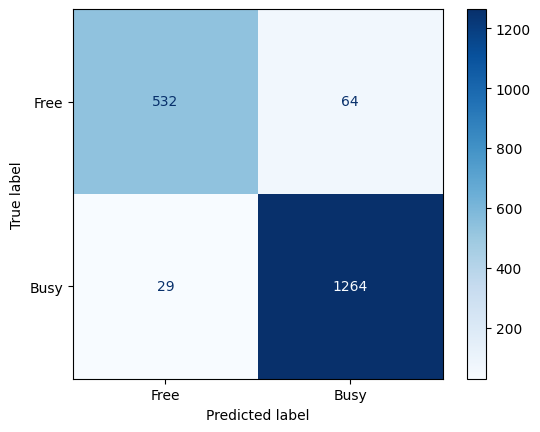

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = efficientnet(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Free", "Busy"])
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [9]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=["Free", "Busy"]))


              precision    recall  f1-score   support

        Free       0.95      0.89      0.92       596
        Busy       0.95      0.98      0.96      1293

    accuracy                           0.95      1889
   macro avg       0.95      0.94      0.94      1889
weighted avg       0.95      0.95      0.95      1889



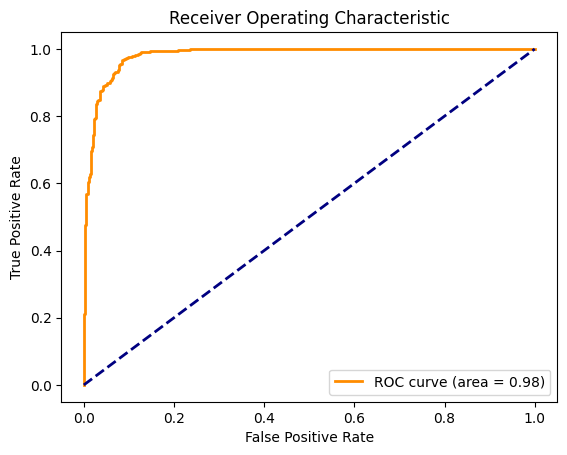

In [10]:
from sklearn.metrics import roc_curve, auc

all_probs = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = efficientnet(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # Probability of 'busy' class
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


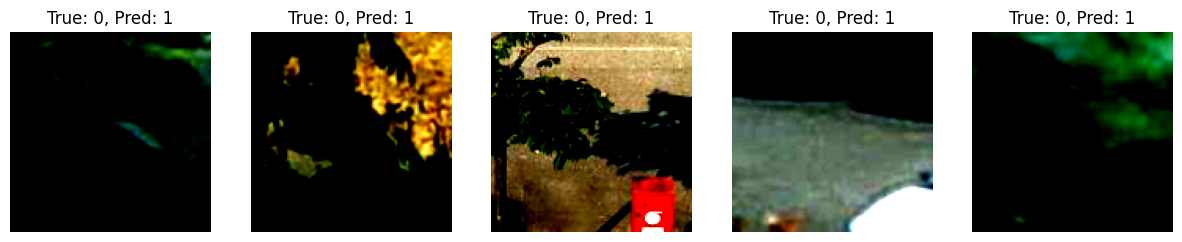

In [11]:
misclassified_images = []
misclassified_labels = []
misclassified_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = efficientnet(images)
        _, preds = torch.max(outputs, 1)
        for i in range(len(preds)):
            if preds[i] != labels[i]:  # If misclassified
                misclassified_images.append(images[i].cpu())
                misclassified_labels.append(labels[i].cpu())
                misclassified_preds.append(preds[i].cpu())

# Plot a few misclassified images
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    image = misclassified_images[i].permute(1, 2, 0).numpy()
    label = misclassified_labels[i].item()
    pred = misclassified_preds[i].item()
    axes[i].imshow(image)
    axes[i].set_title(f"True: {label}, Pred: {pred}")
    axes[i].axis('off')
plt.show()
